## Introduction

Calibrated simulation using semisynthetic data based on the experimentation program dataset.

In [26]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import importlib

import sys
sys.path.append("../../")
import methods  
importlib.reload(methods)

from decision_rules import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Create Synthetic Dataset

We use NPMLE on the experimentation dataset and take the posterior means $\hat{\mu}_i$ as the true mus. Then a new synthetic dataset may be generate by taking $\tilde{Y}_i = \hat{\mu}_i + N(0,\sigma_i^2).$

In [ ]:
synthetic_df = pd.read_csv('data/experimentation_synthetic_dataset.csv', usecols = range(1,6))

## Define Decision Methods

Define functions which give decisions for the given data. We will evaluate the methods by averaging over monte carlo runs where we re-draw the $Y_i$. 

In [47]:
importlib.reload(methods)
np.random.seed(7)


sigmas = np.array(synthetic_df.standard_errors)

mask = (sigmas < 0.045) ## Remove outliers in the dataset.

sigmas = sigmas[mask]
costs = np.array(synthetic_df.costs)[mask]
true_effects = np.array(synthetic_df.true_effects)[mask]
informativeXs = true_effects + sigmas*np.random.standard_t(10,len(true_effects))
noisyXs = 2*sigmas*np.random.standard_t(10,len(true_effects))

Xs = informativeXs

diffs = true_effects - costs
print("Infeasible Oracle:", diffs[diffs > 0].sum())
print(np.corrcoef(true_effects,Xs))

mc_runs = 100

results = {
    'naive_pval': np.zeros(mc_runs),
    'assure_pval': np.zeros(mc_runs),
    'cb_pval': np.zeros(mc_runs),
    'naive_trunc': np.zeros(mc_runs),
    'assure_trunc': np.zeros(mc_runs),
    'cb_trunc': np.zeros(mc_runs),
    'naive_linear_shrink': np.zeros(mc_runs),
    'assure_linear_shrink': np.zeros(mc_runs),
    'cb_linear_shrink': np.zeros(mc_runs),
    'fh': np.zeros(mc_runs),
    'assure_fh': np.zeros(mc_runs),
    'cb_fh': np.zeros(mc_runs),
    'npmle': np.zeros(mc_runs),
    'assure_linear': np.zeros(mc_runs),
    'cb_linear': np.zeros(mc_runs)
}

Infeasible Oracle: 1.3874965726782422
[[1.         0.71702683]
 [0.71702683 1.        ]]


## 

In [109]:
def generate_misspecified_bin_Ys(true_effects, sigmas):
    # pretend data is binomial; use number of observations such that mean of binomial is sigmas
    ns = (true_effects*(1-true_effects)/(sigmas**2)).astype(int)
    data = np.random.binomial(n = ns, p = true_effects)
    return data/ns

def generate_misspecified_t_Ys(true_effects, sigmas):
    return true_effects + sigmas*np.random.standard_t(10,len(true_effects))


def linear_shrink_constantK_threshold_fn(ratio, cost):
    # Consider linear shrinkage to the grand mean where prior_scale controls the amount of
    # shrinkage
    thresh = cost + ratio[None, :] * (sigmas**2)[:, None]
    return thresh

def constant_cost_linear_shrinkage(Ys, sigmas, cost, params, function):
    
    welfare, welfare_se = function(
        Ys,
        sigmas,
        lambda params: linear_shrink_constantK_threshold_fn(params, cost=cost),
        params,
        costs=cost,
    )

    beta_opt = params[np.argmax(welfare)]
    decisions = (Ys >= cost + beta_opt*sigmas**2)
    return decisions.astype(int)



In [ ]:
for i in range(mc_runs):
    print(i)

    #Ys = generate_misspecified_t_Ys(true_effects, sigmas)
    Ys = np.random.normal(true_effects, sigmas)

    ### p < 0.05 P-value Decision
    naive_decisions = get_naive_pval_decisions(Ys = Ys, 
                            sigmas = sigmas, 
                            costs = costs)

    results['naive_pval'][i] = np.sum((true_effects - costs)[np.where(naive_decisions)])
    

    ### ASSURE P-value Decision
    param_grid = np.linspace(-1,1,50)
    assure_decisions = get_assure_pval_decisions(Ys = Ys, 
                            sigmas = sigmas, 
                            costs = costs,
                            param_grid=param_grid[:,np.newaxis])

    results['assure_pval'][i] = np.sum((true_effects - costs)[np.where(assure_decisions)])

    ### CB P-value Decision
    param_grid = np.linspace(-1,1,50)
    cb_pval_decisions = get_cb_pval_decisions(Ys = Ys, 
                            sigmas = sigmas, 
                            costs = costs,
                            param_grid=param_grid[:,np.newaxis])

    results['cb_pval'][i] = np.sum((true_effects - costs)[np.where(cb_pval_decisions)])
    
    ### Naive Truncation (Greater than zero) Decision
    naive_truncation_decisions = get_naive_truncation_decisions(Ys = Ys, 
                            sigmas = sigmas, 
                            costs = costs)

    results['naive_trunc'][i] = np.sum((true_effects - costs)[np.where(naive_truncation_decisions)])


    ### ASSURE Truncation Decision
    param_grid = np.linspace(-0.05,0.05,100)
    assure_truncation_decisions = get_assure_truncation_decisions(Ys = Ys, 
                            sigmas = sigmas, 
                            costs = costs,
                            param_grid=param_grid[:,np.newaxis])

    results['assure_trunc'][i] = np.sum((true_effects - costs)[np.where(assure_truncation_decisions)])


    ### CB Truncation Decision
    param_grid = np.linspace(-0.05,0.05,100)
    cb_truncation_decisions = get_cb_truncation_decisions(Ys = Ys, 
                            sigmas = sigmas, 
                            costs = costs,
                            param_grid=param_grid[:,np.newaxis])

    results['cb_trunc'][i] = np.sum((true_effects - costs)[np.where(cb_truncation_decisions)])
    

    ### Naive Linear Shrinkage (Plug-in EB)
    naive_linear_shrinkage_decisions = get_naive_linear_shrinkage_decisions(Ys = Ys,
                                                                            sigmas=sigmas,
                                                                            costs=costs)
    results['naive_linear_shrink'][i] = np.sum((true_effects - costs)[np.where(naive_linear_shrinkage_decisions)])


    grand_mean = np.mean(Ys)
    grand_var = np.var(Ys) - np.mean(sigmas**2)
    plug_in_eb_param = (cost - grand_mean)/grand_var

    ### ASSURE Linear Shrinkage
    cost = costs[0]
    sorted_thresholds = np.sort((Ys - cost)/sigmas**2)
    mask = (np.abs(sorted_thresholds) < plug_in_eb_param + 5)
    sorted_thresholds = sorted_thresholds[mask]

    assure_linear_shrinkage_decisions = constant_cost_linear_shrinkage(Ys, sigmas, cost, params = sorted_thresholds, function = methods.assure)
    np.sum((true_effects - costs)[np.where(assure_linear_shrinkage_decisions)])
    
    results['assure_linear_shrink'][i] = np.sum((true_effects - costs)[np.where(assure_linear_shrinkage_decisions)])

    cb_linear_shrinkage_decisions = constant_cost_linear_shrinkage(Ys, sigmas, cost, params = sorted_thresholds, function = methods.coupled_bootstrap)
    np.sum((true_effects - costs)[np.where(cb_linear_shrinkage_decisions)])
    results['cb_linear_shrink'][i] = np.sum((true_effects - costs)[np.where(cb_linear_shrinkage_decisions)])


    ### NPMLE Linear Shrinkage
    npmle_decisions, npmle_posterior_means = get_npmle_decisions(Ys, sigmas, costs)
    results['npmle'][i] = np.sum((true_effects - costs)[np.where(npmle_decisions)])


    ### Fay Heriott Methods
    fh_decisions, fh_posterior_means = get_fay_heriott_decisions(Ys, sigmas, costs, Xs.reshape(-1,1))

    results['fh'][i] = np.sum((true_effects - costs)[np.where(fh_decisions)])

    A_vals = np.linspace(0.0001, 0.1, 100)
    beta_vals = np.linspace(-2, 2, 100)
    param_grid = np.stack(np.meshgrid(A_vals, beta_vals, indexing="ij"), axis= -1).reshape(-1, 2)

    assure_fh_decisions = get_assure_fh_decisions(Ys, sigmas, costs, Xs.reshape(-1,1), param_grid)
    results['assure_fh'][i] = np.sum((true_effects - costs)[np.where(assure_fh_decisions)])

    cb_fh_decisions = get_cb_fh_decisions(Ys, sigmas, costs, Xs.reshape(-1,1), param_grid)
    results['cb_fh'][i] = np.sum((true_effects - costs)[np.where(cb_fh_decisions)])


In [140]:
import pickle

fname = f'../results/exp_analysis/exp_program_comparison_normal_mc_runs{mc_runs}_informativeX.pkl'

with open(fname, 'wb') as f:
       pickle.dump(results, f)

# fname = f'../results/exp_analysis/exp_program_comparison_normal_mc_runs{mc_runs}_goodX.pkl'

# with open(fname, 'rb') as f:
#     results = pickle.load(f)

In [141]:
method_names =  {
    'naive_pval': '$p < 0.05$',
    'assure_pval': 'ASSURE $p$-val',
    'cb_pval': 'CB $p$-val',
    'naive_trunc': '$Y_i > 0$',
    'assure_trunc': 'ASSURE thresh',
    'cb_trunc': 'CB thresh',
    'naive_linear_shrink': 'Plug-in Shrinkage',
    'assure_linear_shrink': 'ASSURE Shrinkage',
    'cb_linear_shrink': 'CB Shrinkage',
    'npmle': 'NPMLE',
    'assure_linear': 'ASSURE Linear',
    'cb_linear': 'CB Linear',
    'fh': 'Fay-Herriot (FH)',
    'assure_fh': 'ASSURE FH',
    'cb_fh': 'CB FH'
}

In [142]:


plotted_methods = ['naive_pval',
    'assure_pval',
    'cb_pval',
#    'naive_trunc',
#    'assure_trunc',
#    'cb_trunc',
    'naive_linear_shrink',
    'assure_linear_shrink',
    'cb_linear_shrink',
    'npmle',
#    'assure_linear',
#    'cb_linear',
     'fh',
     'assure_fh',
     'cb_fh'
    ]




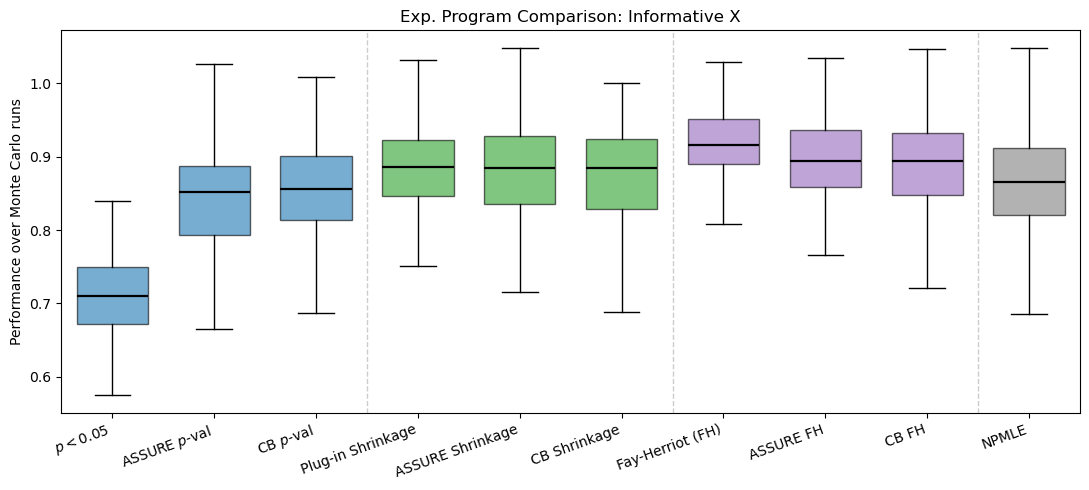

In [186]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def group_of(name: str) -> str:
    if name.endswith("pval"): return "pval"
    if name.endswith("trunc"): return "trunc"
    if name.endswith("shrink"): return "shrink"
    if name.endswith("linear"): return "linear"
    if name.endswith("fh"): return "fh"
    return "other"

group_colors = {
    "pval": "tab:blue",
    "trunc": "tab:orange",
    "shrink": "tab:green",
    "linear": "tab:red",
    "fh": "tab:purple",
    "other": "tab:gray",
}


# order methods by group (pval, trunc, linear_shrink, other)
labels_all = plotted_methods
group_order = {"pval": 0, "trunc": 1, "shrink": 2, "linear": 3, "fh": 4, "other": 5}
order = np.argsort([group_order[group_of(k)] for k in labels_all])

labels = [labels_all[i] for i in order]
data   = [np.asarray(results[k]) for k in labels]
colors = [group_colors[group_of(k)] for k in labels]
groups = [group_of(k) for k in labels]

# positions and plotting
x = np.arange(1, len(labels) + 1)
plt.figure(figsize=(11, 5))
bp = plt.boxplot(
    data,
    positions=x,
    widths=0.7,
    patch_artist=True,
    showfliers=False,   # show outliers
    whis=1.5           # standard Tukey whiskers
)

# color each box (and style whiskers, caps, medians, fliers)
for i in range(len(labels)):
    c = colors[i]
    plt.setp(bp['boxes'][i], facecolor=c, edgecolor='black', alpha=0.6, linewidth=1)
    plt.setp(bp['medians'][i], color='black', linewidth=1.6)
    plt.setp(bp['whiskers'][2*i],   color='black', linewidth=1)
    plt.setp(bp['whiskers'][2*i+1], color='black', linewidth=1)
    plt.setp(bp['caps'][2*i],   color='black', linewidth=1)
    plt.setp(bp['caps'][2*i+1], color='black', linewidth=1)
    # fliers (outliers)
    #if len(bp['fliers']) > i:
    #    plt.setp(bp['fliers'][i], marker='o', markersize=3, markerfacecolor=c, markeredgecolor='black', alpha=0.5)

# x-axis labels
plt.xticks(x, [method_names[labels_all[i]] for i in order], rotation=20, ha="right")
plt.ylabel("Performance over Monte Carlo runs")
plt.title("Method Performance: Box-and-Whisker by Method (group-colored)")

# vertical separators between groups
boundaries = [i for i in range(1, len(groups)) if groups[i] != groups[i-1]]
for b in boundaries:
    plt.axvline(b + 0.5, color='0.8', linewidth=1, linestyle='--', zorder=0)

# legend from present groups
present_groups = []
for g in groups:
    if g not in present_groups:
        present_groups.append(g)
legend_handles = [Patch(facecolor=group_colors[g], edgecolor='black', label=g, alpha=0.6) for g in present_groups]
#plt.legend(handles=legend_handles, title="Group", frameon=True)

plt.tight_layout()
plt.title('Exp. Program Comparison: Informative X')
plt.savefig('../results/exp_analysis/figures/exp_program_comparison_informativeX.pdf', bbox_inches='tight')
plt.show()